# **EXERCICI 3: Identificar gens diferencialment expressats (DEGs)**

## **INTRODUCCIÓ: Què estudiarem?**

Avui et posaràs la bata de bioinformàtica en un experiment de biomedicina real.

Imagina que tenim:

🧍 50 persones sanes (controls)

🧍‍♂️ 50 persones amb una malaltia (casos)

I mirem l'interior de les cèl·lules i mesurem l'activitat de de 1.000 gens en cada persona.

La pregunta clau és:

🔎 Hi ha gens que s'expressen diferent entre malalts i sans?

Si en trobem, aquests gens podrien estar relacionats amb la malaltia, i potser, hi podrem trobar una cura.

## Conceptes clau abans de començar

**1) Expressió gènica: El "termòmetre de l'activitat**

Els gens no només “existeixen” — també s'expressen. Per tant, l'expressió gènica és la quantitat de producte (RNA) que un gen fabrica en un moment determinat.

* Si un gen té una expressió alta, la cèl·lula està posant tota l'energia en aquella funció.


**2) DEG (Differentially Expressed Gene)**

Un gen diferencialment expressat és aquell que presenta un canvi significatiu entre casos i controls. No ens serveixen petites variacions per atzar; busquem gens que clarament tinguin un comportament diferent ente casos i controls.

**3) Problema real en genòmica**

Quan fas 1.000 preguntes a la vegada (una per cada gen), la probabilitat de trobar una resposta que sembli important però que sigui purament per sort és molt alta. L'estadística ens serveix per separar el "senyal real" del "soroll de fons".


En estudis reals analitzem:

* 20.000 gens

* Amb centenars de persones

Això implica fer milers de tests estadístics alhora.

I això genera un problema…

👉 Falsos positius.

## **COMENCEM LA PRÀCTICA**

## Importem paquets

Aquestes llibreries ens permeten:

* Fer tests estadístics

* Corregir per múltiples comparacions

* Visualitzar els resultats

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests


## **PAS 1: Carreguem un dataset simulat**



In [9]:
link_data = "https://raw.githubusercontent.com/bsc-life/Bojos_supercomputacio/refs/heads/main/2026/data/degs_data.txt"

data = pd.read_csv(link_data, sep="\t", na_values=["NA"])

## **PAS 2: Fem un t-test per cada gen**

**Què fem?** Per a cadascun dels 1.000 gens, comparem si la mitjana d'expressió dels malalts és diferent de la dels sans. Obtenim un p-valor i el logFC.

---
**CONCEPTE IMPORTANT: El logFC (log Fold Change): La magnitud del canvi**: A l'exercici anterior usàvem l'Odds Ratio (risc). En expressió gènica fem servir el Fold Change.

Ens diu quantes vegades està més expressat un gen en els malalts respecte als sans.

* logFC > 0: El gen s'expressa més en malalts

* logFC > 0: El gen s'expressa menys en malalts

---

**Per què ho fem?** Necessitem una mesura matemàtica que ens digui si la diferència és gran (logFC) i si ens en podem fiar (p-valor).

* **logFC:** Si és positiu, el gen està més actiu en malalts. Si és negatiu, està més apagat.

* **p-valor:** Si és menor de 0.05, ens diu que hi ha menys d'un 5% de probabilitat que la diferència sigui per pura sort.


In [10]:
p_values = []
logFC = []

for gene in data.index:
    control = data.loc[gene, data.columns[:50]]  # controls
    case    = data.loc[gene, data.columns[50:]]  # casos

    stat, p = ttest_ind(control, case)
    p_values.append(p)

    logFC.append(case.mean() - control.mean())

results = pd.DataFrame({
    "Gene": data.index,
    "logFC": logFC,
    "p_value": p_values
})

results.head()

,Gene,logFC,p_value
0,0,0.600487,0.120925
1,1,-0.214084,0.592291
2,2,0.055075,0.885831
3,3,0.053936,0.892054
4,4,-0.498186,0.288913



**Preguntes per pensar**

* **Què indica un p-valor petit?** Indica que és molt improbable que la diferència que veiem entre sans i malalts sigui fruit de la casualitat.

* **Si el llindar és 0.05, quants falsos positius esperem?** En 1.000 gens, per exemple, n'esperem uns 50. Això és un desastre! Estaríem donant medicaments basant-nos en errors estadístics.

## **PAS 3: Correcció per múltiples tests (FDR)**

Aquí arriba un concepte clau en genòmica.

Quan fem molts tests:

👉 Necessitem corregir els p-valors.

* **Què fem?** Ajustem els p-valors mitjançant el mètode FDR (False Discovery Rate).

* **Per què ho fem?** Perquè no podem acceptar aquests 50 falsos positius. L'FDR és un filtre de seguretat que s'assegura que la majoria de gens que declarem com a "importants" siguin veritables descobriments i no errors estadístics.

In [6]:
results["FDR"] = multipletests(results["p_value"], method="fdr_bh")[1]

**Preguntes a pensar**

* És més estricte FDR que p < 0.05?

* Què passa si no corregim?

## **PAS 4: Definim DEGs**

**Què fem?** Posem el llistó molt alt. Només ens quedem amb els gens que:

* Tenen un FDR < 0.05 (molt fiables).

* Tenen un abs(logFC) > 1 (el canvi és gran, com a mínim el doble d'expressió).

**Per què ho fem?** En medicina busquem canvis que siguin importants. Un canvi molt petit, encara que sigui real, potser no té cap impacte en la salut del pacient.

In [7]:
deg_results = results[
    (abs(results["logFC"]) > 1) &
    (results["FDR"] < 0.05)
]

deg_results.head()

,Gene,logFC,p_value,FDR
10,10,-4.498033,2.042774e-20,4.982376e-19
11,11,5.085595,1.875994e-26,4.689985e-24
16,16,4.919670,3.474440e-24,2.895367e-22
121,121,-5.742416,4.484085e-24,3.449296e-22
193,193,5.077180,1.429292e-22,5.497278e-21


**Preguntes per pensar**

* Per què exigim també un llindar de logFC?

* Què és més important: significació estadística o impacte biològic?

## **PAS 5: Volcano Plot**

**Què fem?** Dibuixem un gràfic on cada punt és un gen.

**Per què ho fem?** És la manera més ràpida de veure el "paisatge" de la malaltia.

**Com llegir els eixos?**

* **Eix X (logFC):** La magnitud del canvi. Com més lluny del centre, més gran és el canvi biològic.

* **Eix Y (-log10 FDR):** La "certesa" o significació estadística. Com més amunt està el punt, més segurs estem que aquest gen és un culpable real i no un fals positiu.

**Com interpretar-lo?**

* Dreta → gens upregulated

* Esquerra → gens downregulated

* Amunt → més significatiu

* Fora de les línies → DEGs

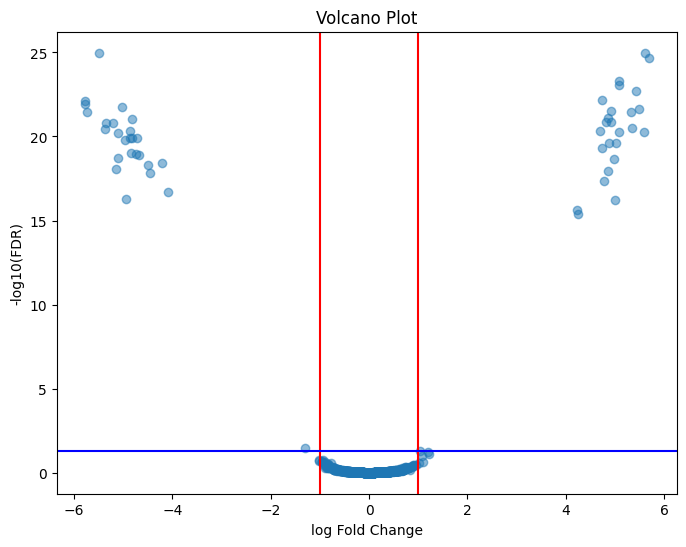

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(results["logFC"], -np.log10(results["FDR"]), alpha=0.5)

plt.axvline(1, color="red")
plt.axvline(-1, color="red")
plt.axhline(-np.log10(0.05), color="blue")

plt.xlabel("log Fold Change")
plt.ylabel("-log10(FDR)")
plt.title("Volcano Plot")
plt.show()

**Pot haver-hi un gen amb gran canvi però no significatiu?** Sí, estaria a un costat però a baix. Això passa quan hi ha molt poques dades o molta variabilitat i l'estadística no es fia de la dada.


**Preguntes per pensar**

* Per què fem -log10(FDR)?

* Per què els gens més interessants estan a les cantonades?

## **Reflexió final**

Hem fet el mateix que es fa en:

* Càncer
* Malalties neurodegeneratives

* COVID

* Immunologia

Identificar gens que canvien pot ajudar a:

* Entendre mecanismes

* Desenvolupar fàrmacs

* Crear biomarcadors

## **Missatge final**

Avui heu:

* Simulat un experiment real

* Aplicat estadística a biologia

* Entès el problema dels múltiples tests

* Interpretat un volcano plot

Això és exactament el que fan bioinformàtics i genetistes.


Heu fet ciència real!!!